In [103]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [104]:
N=5000
nt = 50
STEP = 500

In [105]:
def g(state, t, M, m):
    x, vx, py, vy = state[0], state[1], state[2], state[3] 
    r = (x**2 + py**2)**1.5

    v = np.zeros(4)
    v[0] = vx
    v[1] = -G*M*x / r
    v[2] = vy
    v[3] = -G*M*py / r
    return v

def rungeKutta(y, t, dt, M, m):
    C1 = g(y, t, M, m)
    C2 = g(y + dt*C1/2, t + dt/2, M, m)
    C3 = g(y + dt*C2/2, t + dt/2, M, m)
    C4 = g(y + dt*C3,   t + dt,   M, m)
    return y + dt*(C1 + 2*C2 + 2*C3 + C4)/6

def esperimento(Y0, DT, M, m):
    Y = Y0.copy()

    X1 = np.zeros(N+1)
    Y1 = np.zeros(N+1)
    X1[0] = Y[0]                      
    Y1[0] = Y[2]    

    for i in range(N):
        t = DT*i
        Y = rungeKutta(Y, t, DT + STEP, M, m)
        X1[i+1] = Y[0]               
        Y1[i+1] = Y[2]               

    return X1, Y1


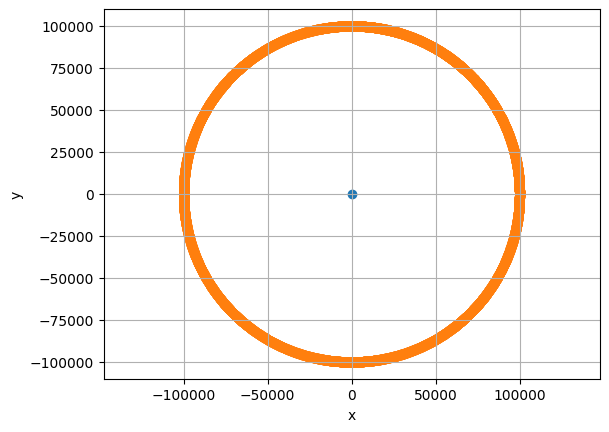

In [106]:
# Orbita circolare

m = 0.1
M = 1e15
G = 6.674e-11

r0 = 100000.0
vc = math.sqrt(G*M/r0)  # Velocità di fuga

Y0 = np.array([r0, 0.0, 0.0, vc*1])
DT = 3*math.pi/nt
X, Y = esperimento(Y0, DT, M, m)
plt.scatter(0,0)
plt.scatter(X, Y)
plt.axis('equal')                     # importante per vedere l'orbita senza distorsioni
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

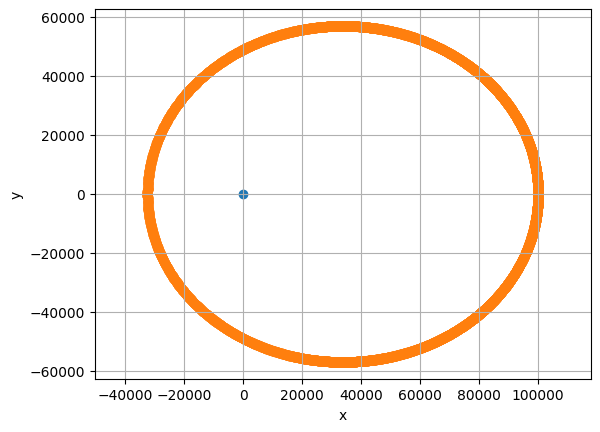

In [107]:
# Orbita Elittica

m = 0.1
M = 1e15
G = 6.674e-11

r0 = 100000.0
vc = math.sqrt(G*M/r0)  # Velocità di fuga

Y0 = np.array([r0, 0.0, 0.0, vc*0.7])
DT = 3*math.pi/nt
X, Y = esperimento(Y0, DT, M, m)
plt.scatter(0,0)
plt.scatter(X, Y)
plt.axis('equal')                     # importante per vedere l'orbita senza distorsioni
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

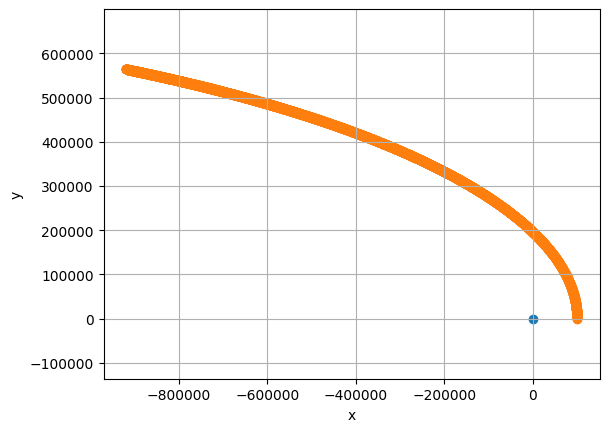

In [108]:
# Orbita Iperbolica

m = 0.1
M = 1e15
G = 6.674e-11

r0 = 100000.0
vc = math.sqrt(G*M/r0)  # Velocità di fuga

Y0 = np.array([r0, 0.0, 0.0, vc*1.4])
DT = 3*math.pi/nt
X, Y = esperimento(Y0, DT, M, m)
plt.scatter(0,0)
plt.scatter(X, Y)
plt.axis('equal')                     # importante per vedere l'orbita senza distorsioni
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()